Lab-12:
 Build a model comparison dashboard – train 4 models, compare results

In [4]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import time, warnings; warnings.filterwarnings('ignore')

import os
if not os.path.exists('diabetes.csv'):
    !wget https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv

df = pd.read_csv('diabetes.csv')
for col in ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']:
  df[col] = df[col].replace(0, df[col].median())
X = df.drop('Outcome', axis=1)
y = df['Outcome']
print(f'Dataset: {X.shape[0]} rows, {X.shape[1]} features')
print(f'Class balance: {y.value_counts().to_dict()}')


Dataset: 768 rows, 8 features
Class balance: {0: 500, 1: 268}


In [5]:
models = {
    'Logistic Regression': Pipeline([('sc',StandardScaler()),
('m',LogisticRegression(max_iter=1000,random_state=42))]),
'Decision Tree' : DecisionTreeClassifier(max_depth=5, random_state=42),
'Random Forest' : RandomForestClassifier(n_estimators=100, random_state=42),
'KNN' : Pipeline([('sc',StandardScaler()),
('m',KNeighborsClassifier(n_neighbors=7))]),
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
metrics = ['accuracy','f1_macro','roc_auc','precision_macro','recall_macro']
records = []
for name, model in models.items():
  t0 = time.time()
  res = cross_validate(model, X, y, cv=cv, scoring=metrics)
  elapsed = time.time()-t0
  row = {'Model': name, 'Time(s)': round(elapsed,2)}
  for m in metrics:
    row[m.replace('_macro','').title()] = round(res[f'test_{m}'].mean(), 4)
    row[f'{m.replace('_macro','').title()}_std'] = round(res[f'test_{m}'].std(), 4)
  records.append(row)
leaderboard = pd.DataFrame(records).sort_values('Accuracy', ascending=False)
print(leaderboard[['Model','Accuracy','F1','Roc_Auc','Precision','Recall','Time(s)']].to_string(index=False))

              Model  Accuracy     F1  Roc_Auc  Precision  Recall  Time(s)
Logistic Regression    0.7708 0.7320   0.8372     0.7602  0.7219     0.15
      Random Forest    0.7577 0.7236   0.8235     0.7367  0.7170     1.70
                KNN    0.7435 0.7026   0.7912     0.7206  0.6948     0.86
      Decision Tree    0.7082 0.6682   0.7516     0.6851  0.6719     0.13


In [7]:
from sklearn.model_selection import cross_val_score

param_grid = {
    'n_estimators' : [50, 100, 200],
'max_depth' : [None, 5, 10],
'min_samples_leaf': [1, 3, 5],
}

gs = GridSearchCV(
RandomForestClassifier(random_state=42),
param_grid, cv=cv, scoring='accuracy',
n_jobs=-1, verbose=0
)
gs.fit(X, y)
print(f'Best params : {gs.best_params_}')
print(f'Best CV acc : {gs.best_score_:.4f}')
default_rf = RandomForestClassifier(n_estimators=100, random_state=42)
default_scores = cross_val_score(default_rf, X, y, cv=cv, scoring='accuracy')
tuned_scores = cross_val_score(gs.best_estimator_, X, y, cv=cv, scoring='accuracy')
print(f'\nDefault RF accuracy: {default_scores.mean():.4f} \u00b1 {default_scores.std():.4f}')
print(f'Tuned RF accuracy: {tuned_scores.mean():.4f} \u00b1 {tuned_scores.std():.4f}')

Best params : {'max_depth': 5, 'min_samples_leaf': 3, 'n_estimators': 50}
Best CV acc : 0.7759

Default RF accuracy: 0.7577 ± 0.0266
Tuned RF accuracy: 0.7759 ± 0.0367


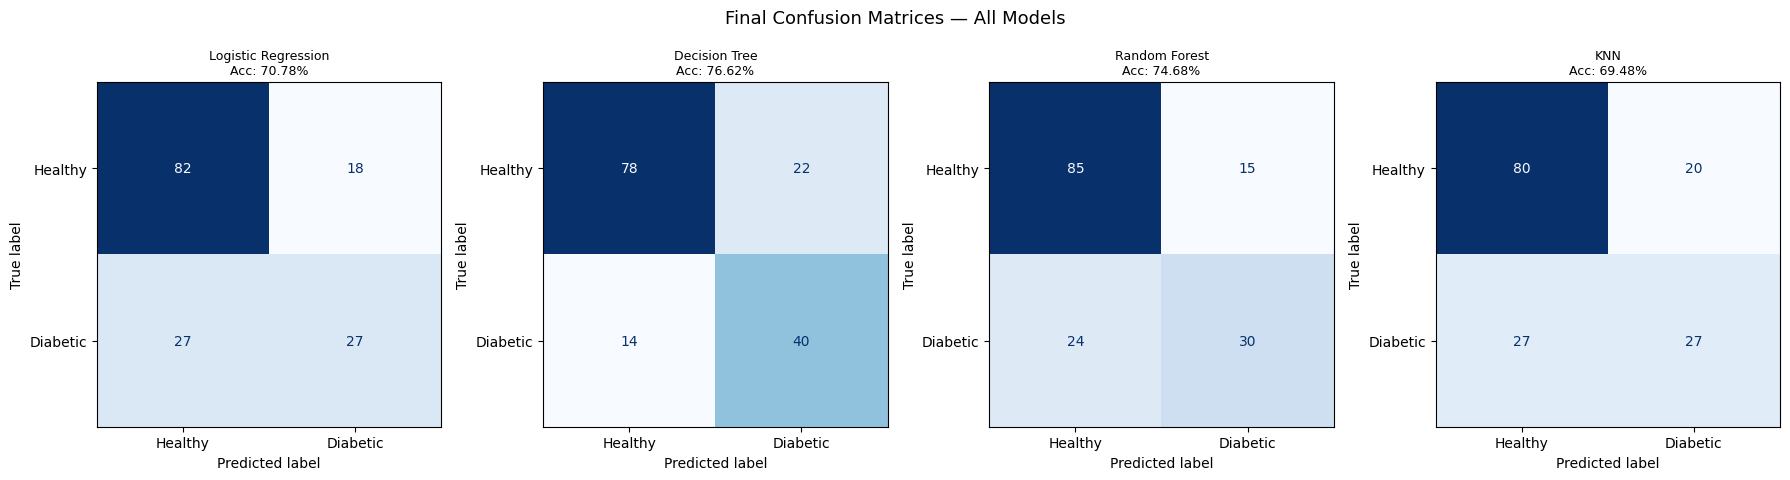


=== FINAL REPORT: Random Forest (Tuned) ===
              precision    recall  f1-score   support

     Healthy       0.78      0.85      0.81       100
    Diabetic       0.67      0.56      0.61        54

    accuracy                           0.75       154
   macro avg       0.72      0.70      0.71       154
weighted avg       0.74      0.75      0.74       154



In [8]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.20, random_state=42, stratify=y)
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
Final_models = {
'Logistic Regression': Pipeline([('sc',StandardScaler()),('m',LogisticRegression(max_iter=1000))]),
'Decision Tree' : DecisionTreeClassifier(max_depth=5, random_state=42),
'Random Forest' : gs.best_estimator_,
'KNN' : Pipeline([('sc',StandardScaler()),('m',KNeighborsClassifier(n_neighbors=7))]),
}
final_results = []
for ax, (name, model) in zip(axes, Final_models.items()):
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  acc = accuracy_score(y_test, y_pred)
  cm = confusion_matrix(y_test, y_pred)
  ConfusionMatrixDisplay(cm, display_labels=['Healthy','Diabetic']).plot(
  ax=ax, cmap='Blues', colorbar=False)
  ax.set_title(f'{name}\nAcc: {acc:.2%}', fontsize=9)
  final_results.append({'Model':name, 'Test Accuracy':f'{acc:.2%}'})
plt.suptitle('Final Confusion Matrices — All Models', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()
best_model = Final_models['Random Forest']
print('\n=== FINAL REPORT: Random Forest (Tuned) ===')
print(classification_report(y_test, best_model.predict(X_test),
target_names=['Healthy','Diabetic']))